# 06. Event Window Price Paths

사례 시점 전후 15거래일(D-15 ~ D+15) 동안, 각 방법이 지목한 연결 노드들의 정규화 가격 경로를 비교합니다.


In [ ]:
!pip install -q yfinance

1. Downloading Standard Data from yfinance...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^JNIV"}}}
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['^RVX', '^JNIV']: YFTzMissingError('possibly delisted; no timezone found')


2. Downloading Macro/Volatility Data from External Sources...
  -> Fetching T5YIE from FRED...
  -> Fetching h_v2tx from STOXX...
3. Merging All Data...

✅ Data successfully downloaded. Generating date-specific plots...


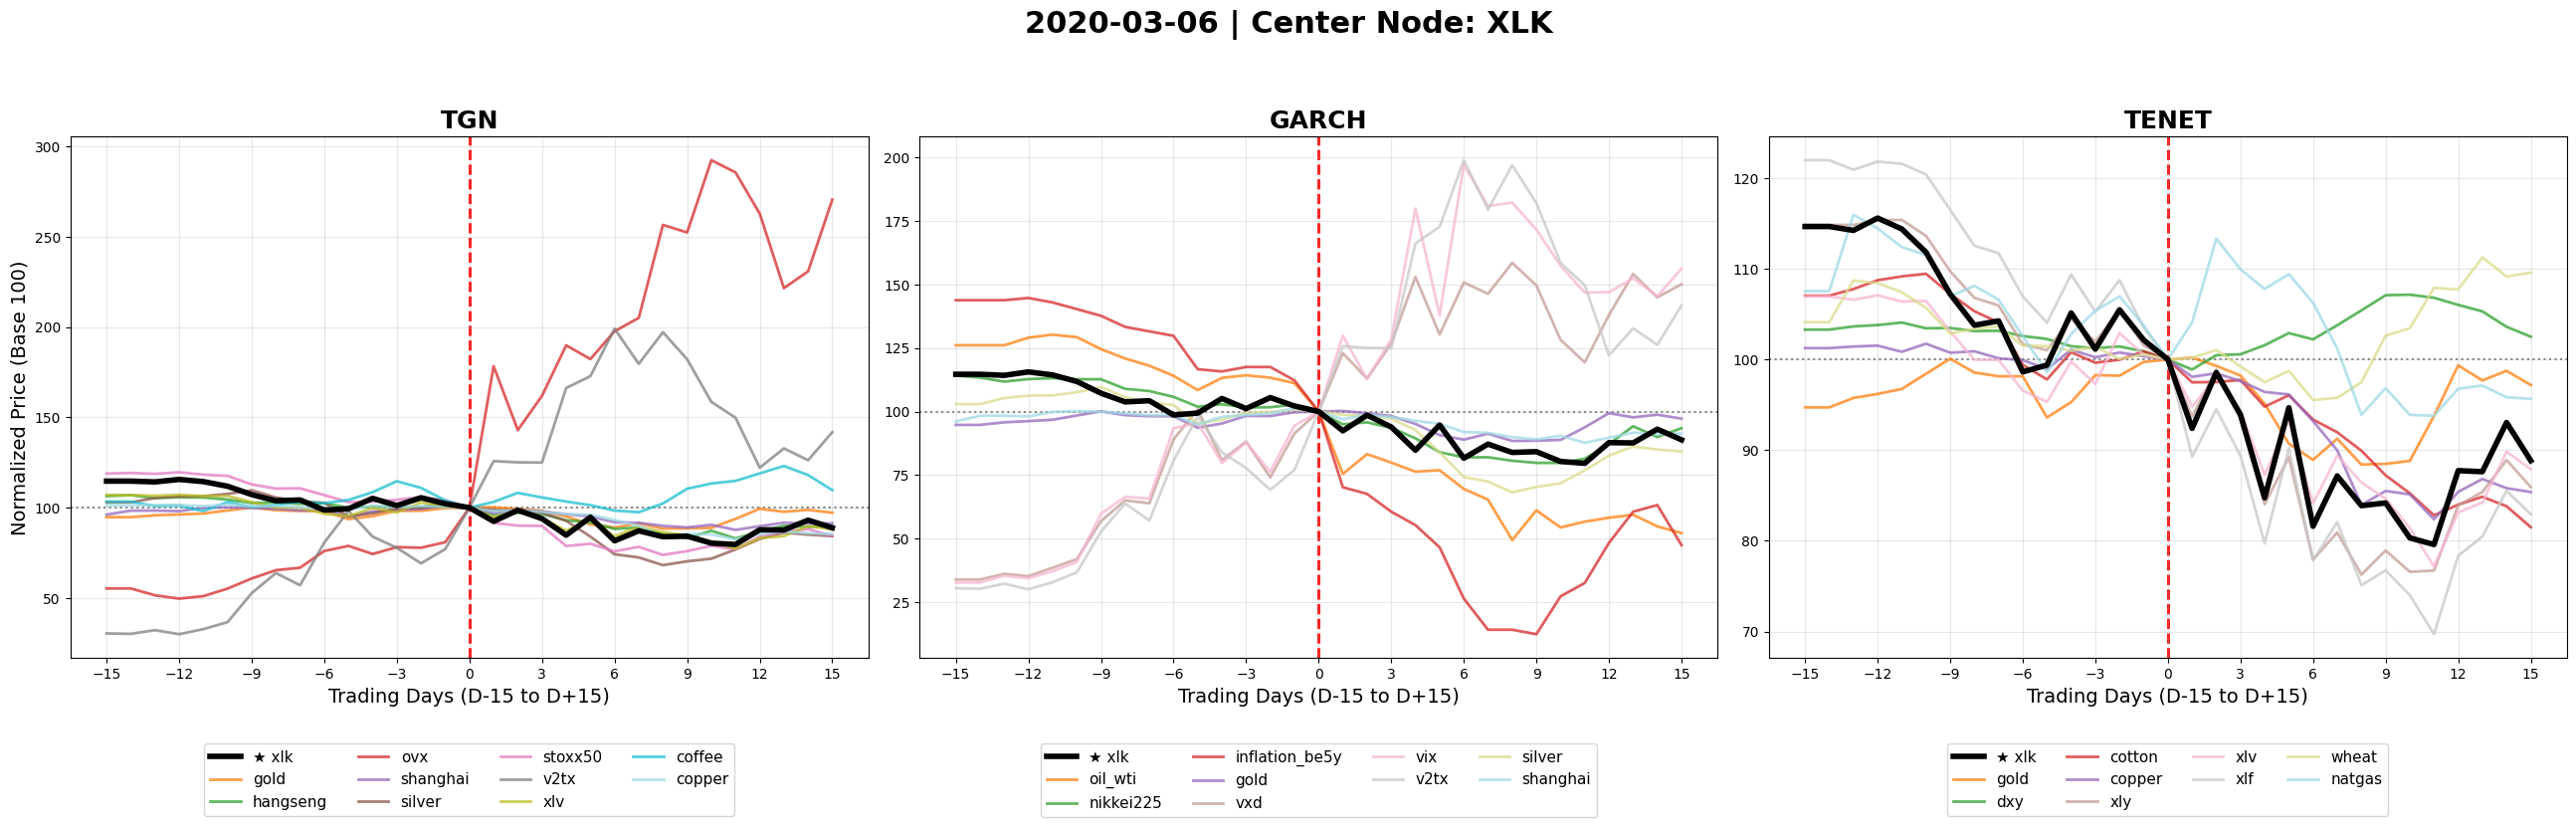

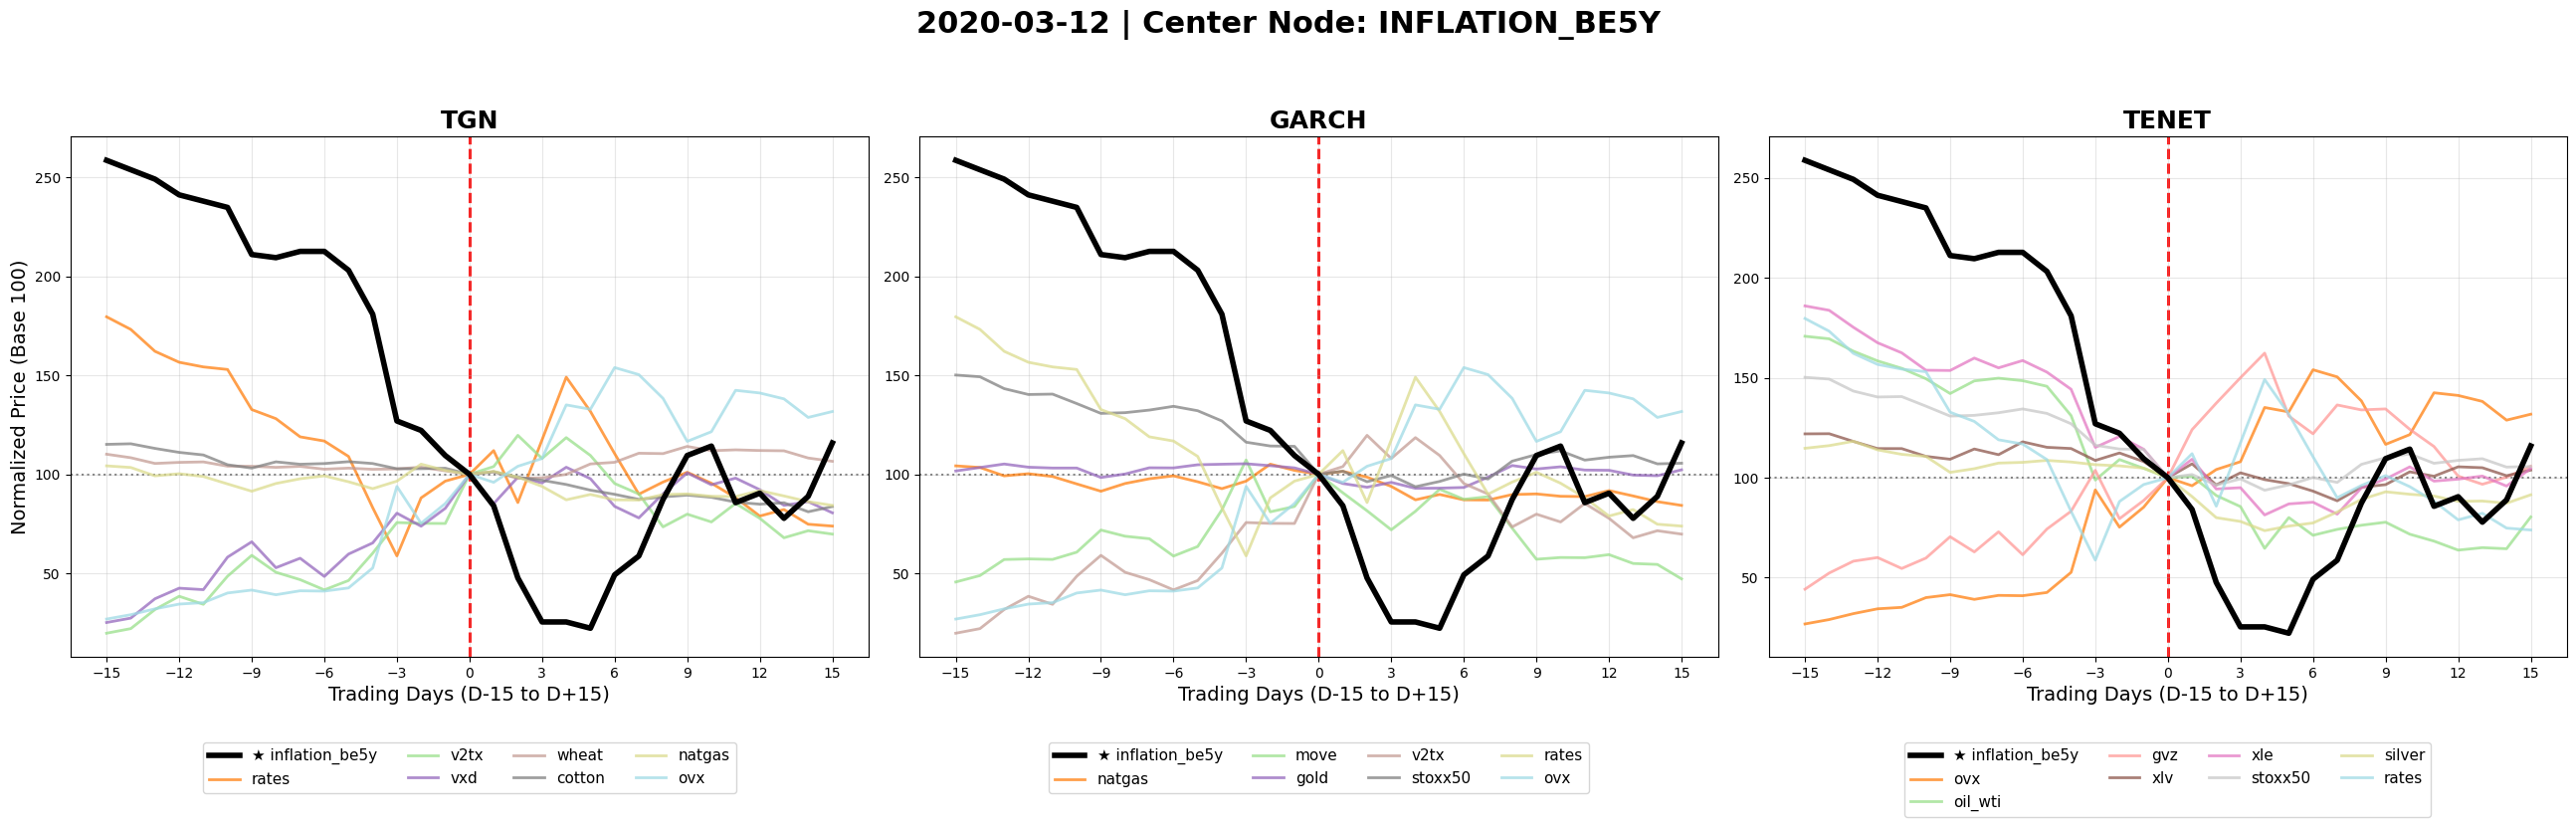

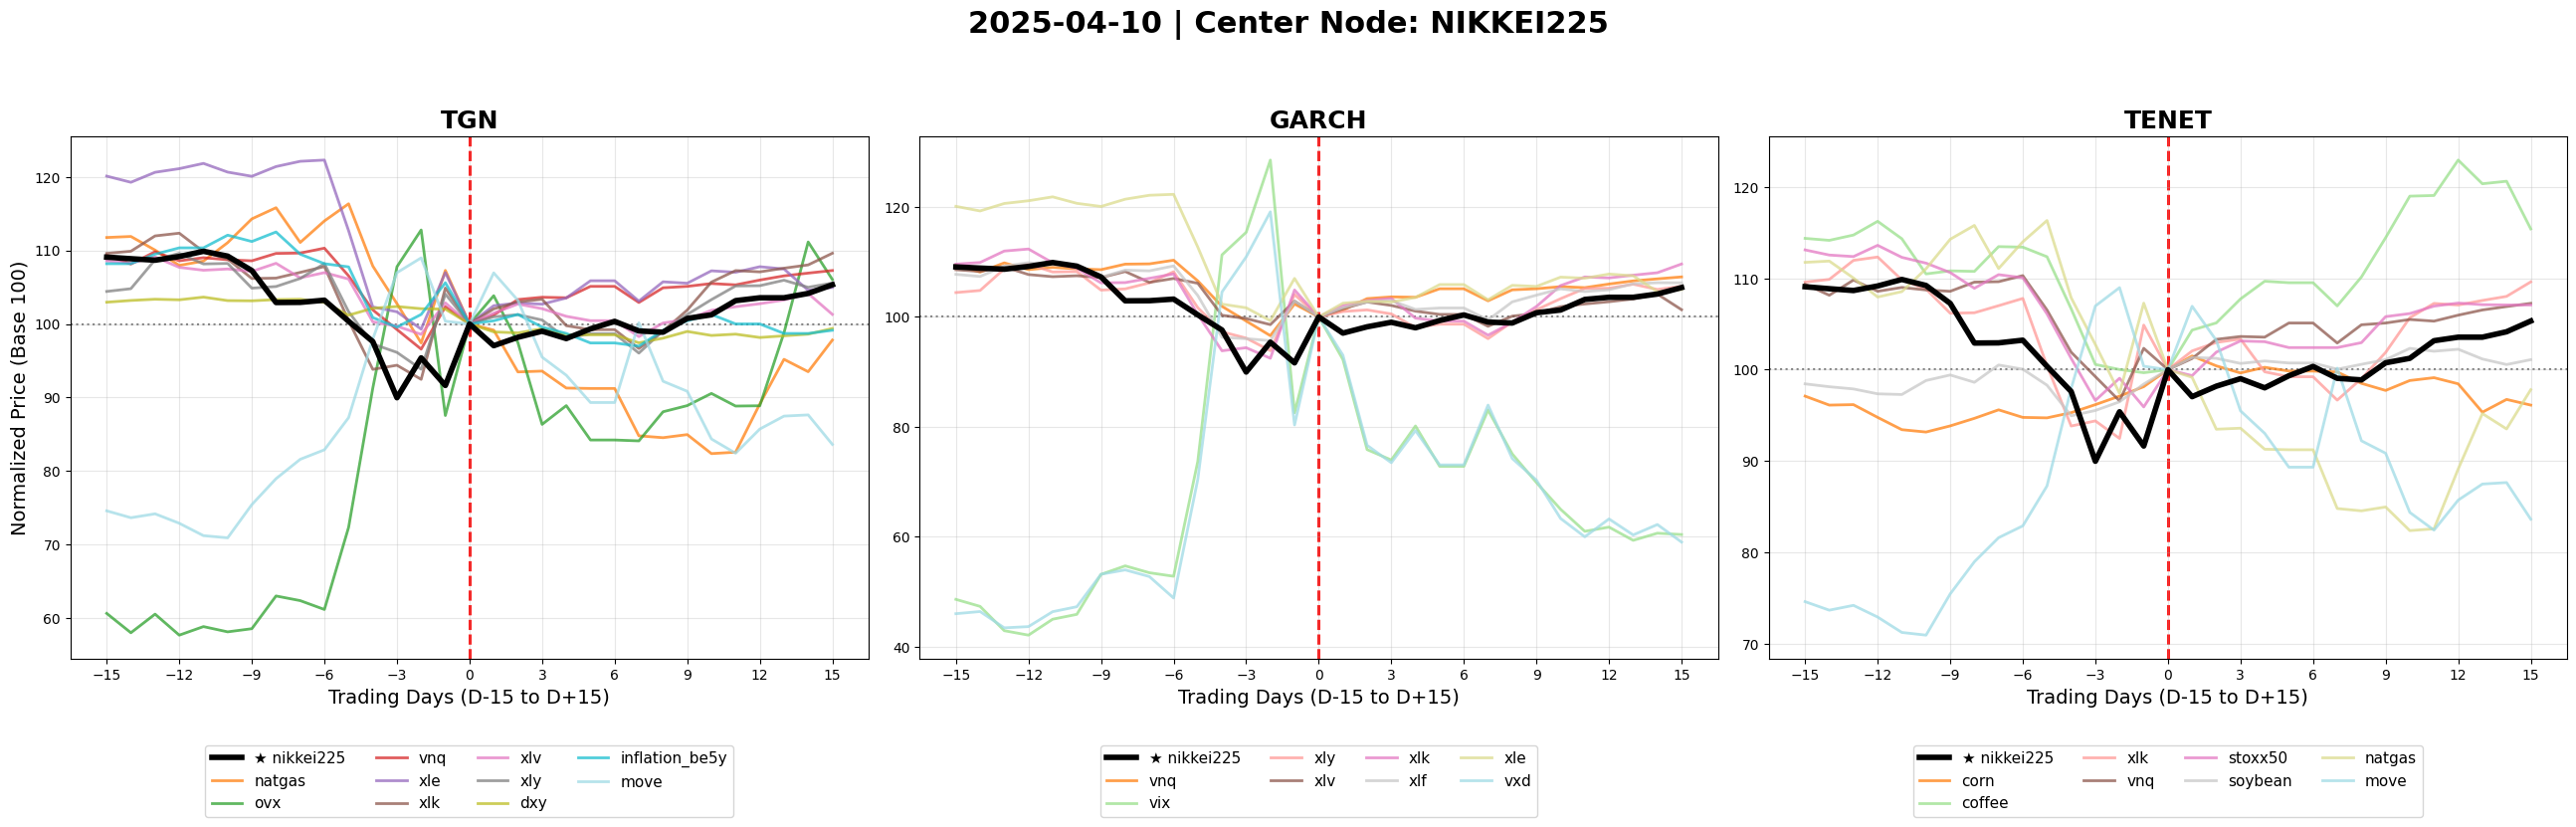

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 0. Configuration & Date-Specific Node Mapping
# ==========================================
NODE_TO_TICKER = {
    'xlk': 'XLK', 'xle': 'XLE', 'xlf': 'XLF', 'xlv': 'XLV', 'xly': 'XLY', 'vnq': 'VNQ',
    'gold': 'GC=F', 'silver': 'SI=F', 'oil_wti': 'CL=F', 'copper': 'HG=F',
    'natgas': 'NG=F', 'wheat': 'ZW=F', 'corn': 'ZC=F', 'soybean': 'ZS=F', 'coffee': 'KC=F', 'cotton': 'CT=F',
    'nikkei225': '^N225', 'shanghai': '000001.SS', 'hangseng': '^HSI', 'stoxx50': '^STOXX50E', 'dxy': 'DX-Y.NYB',
    'rates': '^TNX', 'vix': '^VIX', 'gvz': '^GVZ', 'ovx': '^OVX', 'rvx': '^RVX', 'vxd': '^VXD',
    'move': '^MOVE', 'jniv': '^JNIV'
}

# 💡 핵심 수정 사항: 첨부하신 이미지의 TGN 시각화 노드 결과에 맞춰 완벽하게 동기화했습니다.
EVENT_NODES = {
    '2020-03-06': {
        'center': 'xlk',
        # 이미지 기준: TGN 중심이 nikkei225로 도출되어 있으며, 연결된 노드들 모두 반영
        'TGN': ['xlk', 'gold', 'hangseng','ovx','shanghai','silver','stoxx50','v2tx','xlv','coffee','copper'],
        'GARCH': ['xlk', 'oil_wti', 'nikkei225', 'inflation_be5y', 'gold', 'vxd', 'vix', 'v2tx', 'silver', 'shanghai', 'rvx'],
        'TENET': ['xlk', 'gold', 'dxy', 'cotton', 'copper', 'xly', 'xlv', 'xlf', 'wheat', 'natgas']
    },
    '2020-03-12': {
        'center': 'inflation_be5y',
        # 이미지 기준: TGN 연결 노드들 반영
        'TGN': ['inflation_be5y', 'rates', 'rvx', 'v2tx', 'vxd', 'vxn', 'wheat', 'cotton', 'jniv', 'natgas', 'ovx'],
        'GARCH': ['inflation_be5y', 'natgas', 'move', 'gold', 'v2tx', 'stoxx50', 'rvx', 'rates', 'ovx'],
        'TENET': ['inflation_be5y', 'ovx', 'oil_wti', 'gvz', 'xlv', 'xle', 'stoxx50', 'silver', 'rates']
    },
    '2025-04-10': {
        'center': 'nikkei225',
        # 이미지 기준: TGN 연결 노드들 반영
        'TGN': ['nikkei225', 'natgas', 'ovx', 'vnq', 'xle', 'xlk', 'xlv', 'xly', 'dxy', 'inflation_be5y', 'move'],
        'GARCH': ['nikkei225', 'vnq', 'vix', 'rvx', 'xly', 'xlv', 'xlk', 'xlf', 'xle', 'vxd'],
        'TENET': ['nikkei225', 'jniv', 'corn', 'coffee', 'xlk', 'vnq', 'stoxx50', 'soybean', 'natgas', 'move']
    }
}

TARGET_DATES = list(EVENT_NODES.keys())
WINDOW_DAYS = 15

# ==========================================
# 1. Custom Data Fetchers
# ==========================================
def fetch_fred(sid: str, start="2019-01-01") -> pd.Series:
    print(f"  -> Fetching {sid} from FRED...")
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}&cosd={start}"
    try:
        s = pd.read_csv(url, na_values=".")
        s.columns = ["date", "v"]
        s["date"] = pd.to_datetime(s["date"])
        return s.dropna().set_index("date")["v"]
    except Exception as e:
        print(f"     Failed to fetch {sid}: {e}")
        return pd.Series(dtype=float)

def fetch_stoxx(doc: str, start="2019-01-01") -> pd.Series:
    print(f"  -> Fetching {doc} from STOXX...")
    url = f"https://www.stoxx.com/document/Indices/Current/HistoricalData/{doc}.txt"
    try:
        df = pd.read_csv(url, sep=";")
        df["date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y")
        s = df.sort_values("date").set_index("date")["Indexvalue"].astype(float)
        return s[s.index >= pd.Timestamp(start)]
    except Exception as e:
        print(f"     Failed to fetch {doc}: {e}")
        return pd.Series(dtype=float)

def load_all_prices():
    print("1. Downloading Standard Data from yfinance...")
    valid_tickers = list(NODE_TO_TICKER.values())
    yf_df = yf.download(valid_tickers, start="2019-01-01", end="2026-12-31", progress=False)['Close']

    ticker_to_node = {v: k for k, v in NODE_TO_TICKER.items()}
    yf_df.columns = [ticker_to_node.get(c, c) for c in yf_df.columns]
    yf_df.index = yf_df.index.tz_localize(None)

    print("2. Downloading Macro/Volatility Data from External Sources...")
    inf_df = fetch_fred("T5YIE").to_frame("inflation_be5y")
    v2tx_df = fetch_stoxx("h_v2tx").to_frame("v2tx")

    print("3. Merging All Data...")
    all_df = pd.concat([yf_df, inf_df, v2tx_df], axis=1)
    all_df = all_df.dropna(how='all').ffill()
    return all_df

# ==========================================
# 2. Plotting Event Windows
# ==========================================
def plot_event_windows(df, window, event_dict):
    models = ['TGN', 'GARCH', 'TENET']

    for target_str, group_data in event_dict.items():
        target_dt = pd.Timestamp(target_str)
        center_node = group_data['center']

        # 날짜 매칭 로직
        if target_dt not in df.index:
            try:
                nearest_idx = df.index.get_indexer([target_dt], method='ffill')[0]
                if nearest_idx == -1: nearest_idx = df.index.get_indexer([target_dt], method='bfill')[0]
                actual_date = df.index[nearest_idx]
            except:
                print(f"Error finding date near {target_str}. Skipping.")
                continue
        else:
            actual_date = target_dt
            nearest_idx = df.index.get_loc(actual_date)

        start_idx = max(0, nearest_idx - window)
        end_idx = min(len(df) - 1, nearest_idx + window)

        window_df = df.iloc[start_idx : end_idx + 1].copy()
        relative_days = np.arange(start_idx - nearest_idx, end_idx - nearest_idx + 1)
        center_values = df.iloc[nearest_idx]
        normalized_df = (window_df / center_values) * 100

        # 1개의 Figure에 3개의 Subplot
        fig, axes = plt.subplots(1, 3, figsize=(26, 8))
        fig.suptitle(f"{actual_date.strftime('%Y-%m-%d')} | Center Node: {center_node.upper()}", fontsize=22, fontweight='bold', y=1.05)

        for idx, model_name in enumerate(models):
            ax = axes[idx]
            target_nodes = group_data[model_name]

            # 유효한 노드만 필터링 (결측 방지)
            valid_nodes = [node for node in target_nodes if node in normalized_df.columns and not normalized_df[node].isnull().all()]
            model_df = normalized_df[valid_nodes]

            colors = plt.cm.tab20(np.linspace(0, 1, len(valid_nodes)))

            for j, col in enumerate(model_df.columns):
                # 💡 중심 노드(Center Node)는 검정색+두껍게 강조
                # 예외 처리: 2020-03-06의 TGN처럼 중심 노드가 center_node 변수와 다르게 도출된 경우, TGN 리스트의 첫 번째 요소를 임시 중심으로 강조
                visual_center = target_nodes[0] if (model_name == 'TGN' and target_str == '2020-03-06') else center_node

                if col == visual_center:
                    ax.plot(relative_days, model_df[col], label=f"★ {col}", color='black', linewidth=4.0, zorder=5)
                else:
                    ax.plot(relative_days, model_df[col], label=col, color=colors[j], linewidth=2.0, alpha=0.75, zorder=3)

            ax.axvline(x=0, color='red', linestyle='--', linewidth=2.0, zorder=1)
            ax.axhline(y=100, color='gray', linestyle=':', linewidth=1.5, zorder=1)

            # Subplot 설정
            ax.set_title(f"{model_name}", fontsize=18, fontweight='bold')
            ax.set_xlabel(f"Trading Days (D-{window} to D+{window})", fontsize=14)

            if idx == 0:
                ax.set_ylabel("Normalized Price (Base 100)", fontsize=14)

            ax.grid(True, alpha=0.3, zorder=0)
            ax.set_xticks(np.arange(-window, window + 1, 3))

            # 범례 하단 배치
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=11, ncol=4)

        plt.tight_layout()
        plt.show()

# ==========================================
# 3. Main Execution
# ==========================================
if __name__ == "__main__":
    prices_df = load_all_prices()
    print("\n✅ Data successfully downloaded. Generating date-specific plots...")
    plot_event_windows(prices_df, WINDOW_DAYS, EVENT_NODES)